In [12]:
from IPython.display import Video

Video("outputs/boston-celtics-new-york-knicks-game-1-q1-04.28-04.20/boston-celtics-new-york-knicks-game-1-q1-04.28-04.20-detections.mp4", embed=True, width=720)

In [30]:
from pathlib import Path

SOURCE_VIDEO_PATH = "/workspace/Basketball-player-tracking/data/boston-celtics-new-york-knicks-game-1-q1-03.16-03.11.mp4"

In [15]:
import numpy as np

import supervision as sv
from inference import get_model
from sports import (
    clean_paths,
    ConsecutiveValueTracker,
    TeamClassifier,
    MeasurementUnit,
    ViewTransformer
)
from sports.basketball import (
    CourtConfiguration,
    League,
    draw_court,
    draw_points_on_court,
    draw_paths_on_court,
    draw_made_and_miss_on_court,
    ShotEventTracker
)

[08/21/26 14:42:37] WARNING  Your inference package version 1.3.7 is out of date! Please upgrade to  ]8;id=9289618;file:///workspace/Basketball-player-tracking/.venv/lib/python3.11/site-packages/inference/core/__init__.py\__init__.py]8;;\:]8;id=9289619;file:///workspace/Basketball-player-tracking/.venv/lib/python3.11/site-packages/inference/core/__init__.py#50\50]8;;\
                             version 1.4.1 of inference for the latest features and bug fixes by                   
                             running `pip install --upgrade inference`.                                            

ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM_ENABLED to False.
[transformers] `DepthProImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `DepthProImageProcessor` instead.
ModelDependencyMissing: Your `inference` configuration does not support YoloWorld model. Use pip install 'inference[yolo-world]' to install missing requirements.To suppress this warning, set CORE_MODEL_YOLO_WORLD_ENABLED to False.


In [16]:
PLAYER_DETECTION_MODEL_ID = "basketball-player-detection-3-ycjdo/4"
PLAYER_DETECTION_MODEL_CONFIDENCE = 0.4
PLAYER_DETECTION_MODEL_IOU_THRESHOLD = 0.9
PLAYER_DETECTION_MODEL = get_model(model_id=PLAYER_DETECTION_MODEL_ID)

KEYPOINT_DETECTION_MODEL_ID = "basketball-court-detection-2/14"
KEYPOINT_DETECTION_MODEL_CONFIDENCE = 0.3
KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE = 0.5
KEYPOINT_DETECTION_MODEL = get_model(model_id=KEYPOINT_DETECTION_MODEL_ID)
KEYPOINT_COLOR = sv.Color.from_hex('#FF1493')

COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

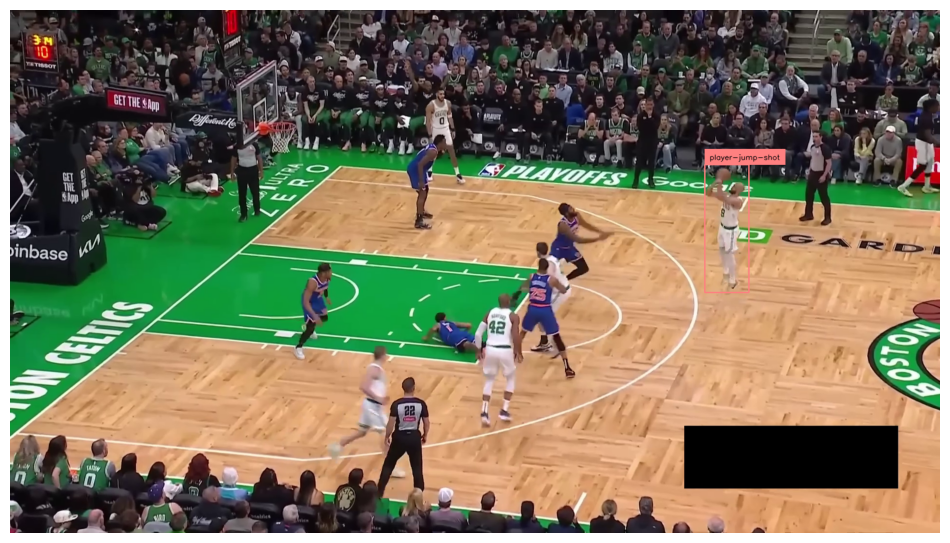

In [32]:
PLAYER_JUMP_SHOT_CLASS_ID = 5
FRAME_IDX = 65

box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=FRAME_IDX, iterative_seek=True)
frame = next(frame_generator)

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[detections.class_id == PLAYER_JUMP_SHOT_CLASS_ID]

annotated_frame = frame.copy()
annotated_frame = box_annotator.annotate(
    scene=annotated_frame,
    detections=detections)
annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=detections)

sv.plot_image(annotated_frame)

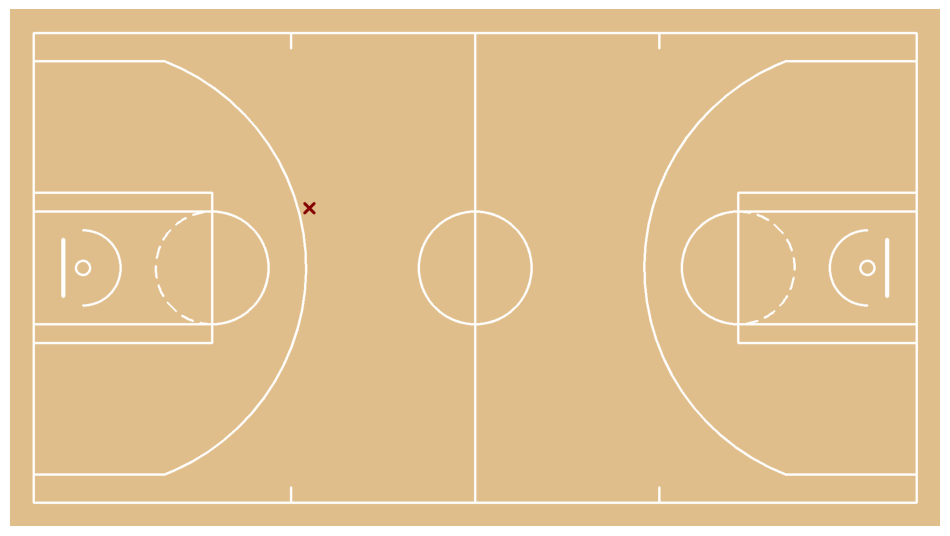

In [42]:
config = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=FRAME_IDX, iterative_seek=True)
frame = next(frame_generator)

# we use a RF-DETR model to detect players

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[detections.class_id == PLAYER_JUMP_SHOT_CLASS_ID]

# we use a keypoint model to detect court landmarks

result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE)[0]
key_points = sv.KeyPoints.from_inference(result)
landmarks_mask = key_points.keypoint_confidence[0] > KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE

if np.count_nonzero(landmarks_mask) >= 4:

    # we calculate homography matrix

    court_landmarks = np.array(config.vertices)[landmarks_mask]
    frame_landmarks = key_points[:, landmarks_mask].xy[0]

    frame_to_court_transformer = ViewTransformer(
        source=frame_landmarks,
        target=court_landmarks,
    )

    frame_xy = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)

    # transform video frame coordinates into court coordinates

    court_xy = frame_to_court_transformer.transform_points(points=frame_xy)

    court = draw_made_and_miss_on_court(
        config=config,
        miss_xy=court_xy,
        miss_color = sv.Color.from_hex("#850101"),
        miss_size= 10,
        made_size=25,
        made_color=sv.Color.from_hex("#007A33"),
        made_thickness=6,
        miss_thickness=6,
        line_thickness=4
    )

    sv.plot_image(court)

[{'event': 'START', 'frame': 64, 'type': 'JUMP'}]


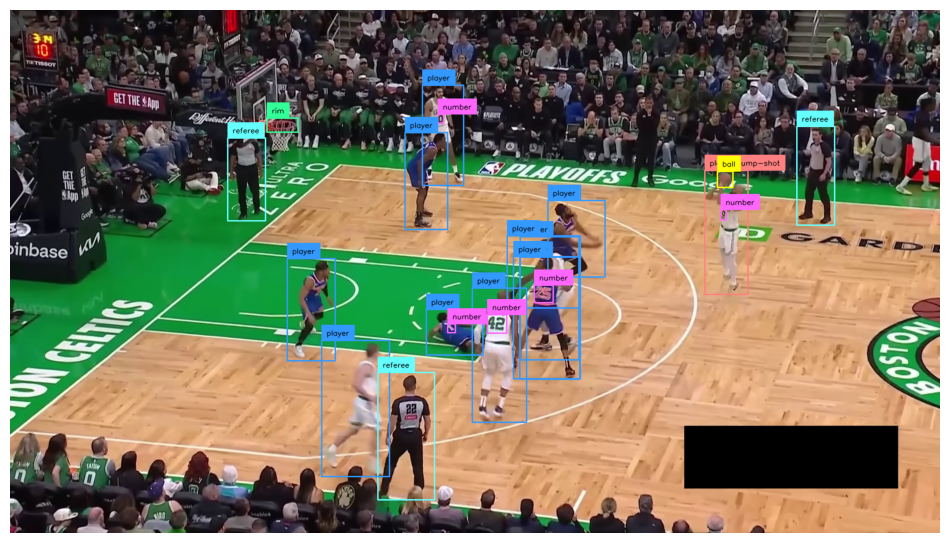

[{'event': 'MISSED', 'frame': 115, 'type': 'JUMP'}]


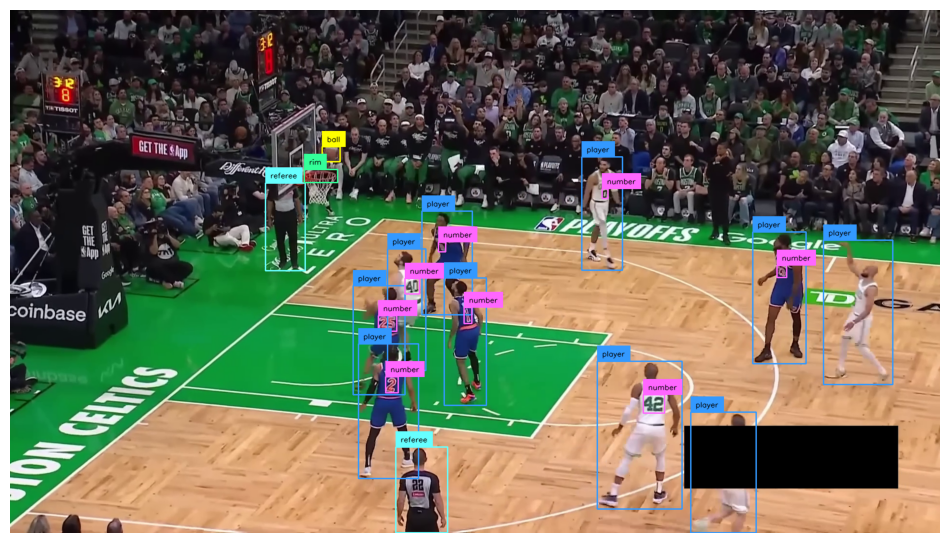

[{'event': 'START', 'frame': 121, 'type': 'LAYUP'}]


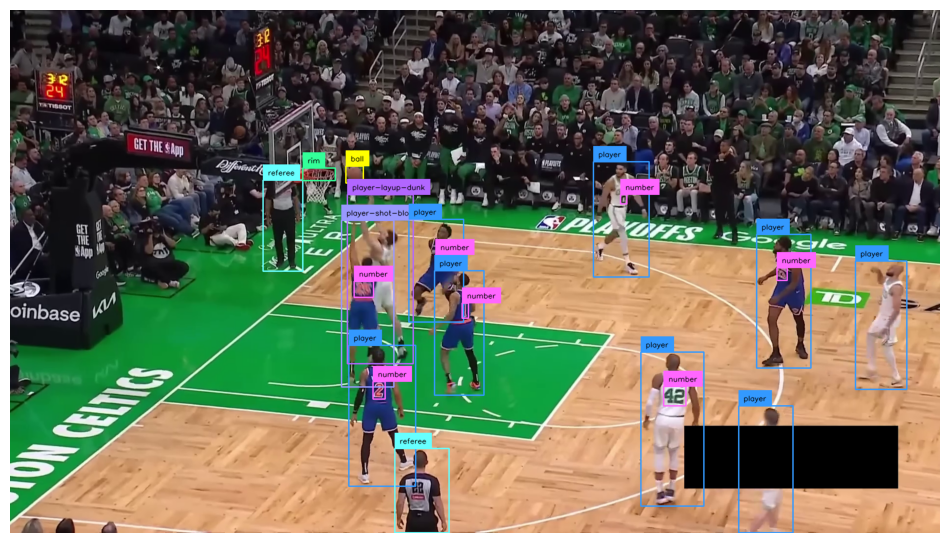

[{'event': 'MADE', 'frame': 135, 'type': 'LAYUP'}]


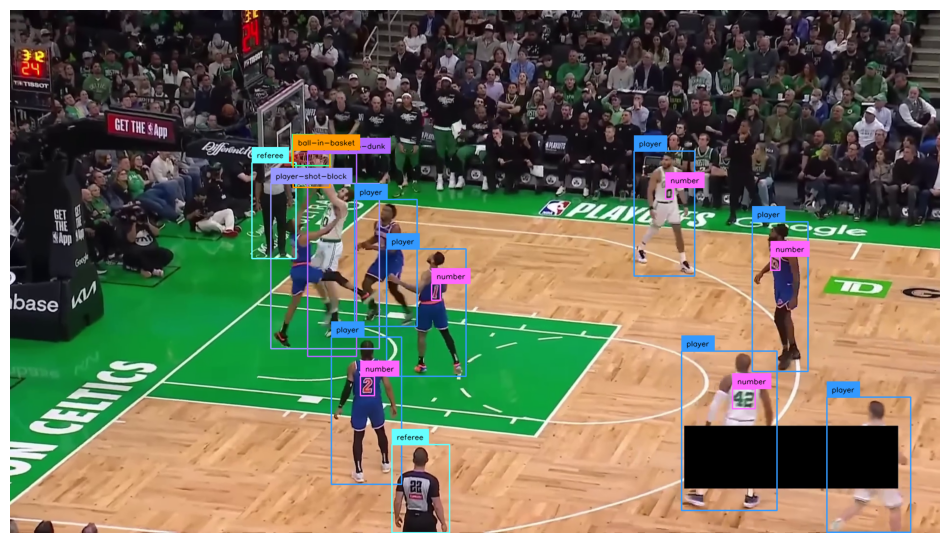

In [34]:
BALL_IN_BASKET_CLASS_ID = 1
JUMP_SHOT_CLASS_ID = 5
LAYUP_DUNK_CLASS_ID = 6

box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

shot_event_tracker = ShotEventTracker(
    reset_time_frames=int(video_info.fps * 1.7),
    minimum_frames_between_starts=int(video_info.fps * 0.5),
    cooldown_frames_after_made=int(video_info.fps * 0.5),
)

for frame_index, frame in enumerate(frame_generator):

    # we use a RF-DETR model to detect jump shot, layup, dunk and ball in basket

    result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
    detections = sv.Detections.from_inference(result)

    has_jump_shot = len(detections[detections.class_id == JUMP_SHOT_CLASS_ID]) > 0
    has_layup_dunk = len(detections[detections.class_id == LAYUP_DUNK_CLASS_ID]) > 0
    has_ball_in_basket = len(detections[detections.class_id == BALL_IN_BASKET_CLASS_ID]) > 0

    events = shot_event_tracker.update(
        frame_index=frame_index,
        has_jump_shot=has_jump_shot,
        has_layup_dunk=has_layup_dunk,
        has_ball_in_basket=has_ball_in_basket,
    )

    if events:
        print(events)

        annotated_frame = frame.copy()
        annotated_frame = box_annotator.annotate(
            scene=annotated_frame,
            detections=detections)
        annotated_frame = label_annotator.annotate(
            scene=annotated_frame,
            detections=detections)

        sv.plot_image(annotated_frame)